In [32]:
import pandas as pd


In [33]:
import os
print(os.getcwd())  # Check current working directory

c:\Users\shema\Documents\VScodeProject\Project2\Hackathon-2\jupyter_notebooks


In [34]:
df = pd.read_csv("Data/input/raw/BankChurners.csv")
df



,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.999910
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.999940
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.999980
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.999870
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.999980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,772366833,Existing Customer,50,M,2,Graduate,Single,$40K - $60K,Blue,40,...,4003.0,1851,2152.0,0.703,15476,117,0.857,0.462,0.000191,0.999810
10123,710638233,Attrited Customer,41,M,2,Unknown,Divorced,$40K - $60K,Blue,25,...,4277.0,2186,2091.0,0.804,8764,69,0.683,0.511,0.995270,0.004729
10124,716506083,Attrited Customer,44,F,1,High School,Married,Less than $40K,Blue,36,...,5409.0,0,5409.0,0.819,10291,60,0.818,0.000,0.997880,0.002118
10125,717406983,Attrited Customer,30,M,2,Graduate,Unknown,$40K - $60K,Blue,36,...,5281.0,0,5281.0,0.535,8395,62,0.722,0.000,0.996710,0.003294


## Data clean and Transformation
I have started with a basic data clean below

In [35]:
# Drop duplicate rows if any
df = df.drop_duplicates()

# Check for missing values and display the count per column
missing_counts = df.isnull().sum()
print("Missing values per column:\n", missing_counts)

# For simplicity, drop rows with any missing values
df = df.dropna()

# Reset index after cleaning
df = df.reset_index(drop=True)

# Show the cleaned dataframe info
df.info()

Missing values per column:
 CLIENTNUM                                                                                                                             0
Attrition_Flag                                                                                                                        0
Customer_Age                                                                                                                          0
Gender                                                                                                                                0
Dependent_count                                                                                                                       0
Education_Level                                                                                                                       0
Marital_Status                                                                                                                        0
Income_Category     

In [36]:
df.columns = df.columns.str.lower().str.replace(" ", "_")  #Standardized column names
df

,clientnum,attrition_flag,customer_age,gender,dependent_count,education_level,marital_status,income_category,card_category,months_on_book,...,credit_limit,total_revolving_bal,avg_open_to_buy,total_amt_chng_q4_q1,total_trans_amt,total_trans_ct,total_ct_chng_q4_q1,avg_utilization_ratio,naive_bayes_classifier_attrition_flag_card_category_contacts_count_12_mon_dependent_count_education_level_months_inactive_12_mon_1,naive_bayes_classifier_attrition_flag_card_category_contacts_count_12_mon_dependent_count_education_level_months_inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.999910
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.999940
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.999980
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.999870
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.999980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,772366833,Existing Customer,50,M,2,Graduate,Single,$40K - $60K,Blue,40,...,4003.0,1851,2152.0,0.703,15476,117,0.857,0.462,0.000191,0.999810
10123,710638233,Attrited Customer,41,M,2,Unknown,Divorced,$40K - $60K,Blue,25,...,4277.0,2186,2091.0,0.804,8764,69,0.683,0.511,0.995270,0.004729
10124,716506083,Attrited Customer,44,F,1,High School,Married,Less than $40K,Blue,36,...,5409.0,0,5409.0,0.819,10291,60,0.818,0.000,0.997880,0.002118
10125,717406983,Attrited Customer,30,M,2,Graduate,Unknown,$40K - $60K,Blue,36,...,5281.0,0,5281.0,0.535,8395,62,0.722,0.000,0.996710,0.003294


## Indepth Data Clean

In [37]:
# Remove outliers based on IQR for specified numeric columns
# customer_age – Identify unusually young or old customers that might skew analysis.
# credit_limit – Remove extreme high or low limits that could distort financial insights.
# total_trans_amt – Detect unusually high or low transaction amounts to refine spend patterns.
# total_trans_ct – Identify customers with excessive or minimal transactions.
# avg_utilization_ratio – Spot extreme credit utilization rates that might indicate riskier customers.

numeric_cols = ['customer_age', 'credit_limit', 'total_trans_amt', 'total_trans_ct', 'avg_utilization_ratio'] 

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    df = df[(df[col] >= (Q1 - 1.5 * IQR)) & (df[col] <= (Q3 + 1.5 * IQR))]
    print(df)

       clientnum     attrition_flag  customer_age gender  dependent_count  \
0      768805383  Existing Customer            45      M                3   
1      818770008  Existing Customer            49      F                5   
2      713982108  Existing Customer            51      M                3   
3      769911858  Existing Customer            40      F                4   
4      709106358  Existing Customer            40      M                3   
...          ...                ...           ...    ...              ...   
10122  772366833  Existing Customer            50      M                2   
10123  710638233  Attrited Customer            41      M                2   
10124  716506083  Attrited Customer            44      F                1   
10125  717406983  Attrited Customer            30      M                2   
10126  714337233  Attrited Customer            43      F                2   

      education_level marital_status income_category card_category  \
0    

In [38]:
print("Before filtering:", df.shape)

Before filtering: (8418, 23)


In [39]:
print("After filtering:", df.shape)


After filtering: (8418, 23)


In [40]:
print(df[numeric_cols].describe())  #Compare summary statistics

       customer_age  credit_limit  total_trans_amt  total_trans_ct  \
count   8418.000000   8418.000000      8418.000000     8418.000000   
mean      46.431932   5907.891673      3459.803397       60.916370   
std        8.119002   5109.962653      1596.448289       19.978393   
min       26.000000   1438.300000       510.000000       10.000000   
25%       41.000000   2353.250000      2062.250000       43.000000   
50%       46.000000   3610.500000      3672.000000       65.000000   
75%       52.000000   7925.750000      4518.000000       77.000000   
max       68.000000  23742.000000      8463.000000      113.000000   

       avg_utilization_ratio  
count            8418.000000  
mean                0.308057  
std                 0.283295  
min                 0.000000  
25%                 0.000000  
50%                 0.232500  
75%                 0.557000  
max                 0.999000  


In [41]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Extreme Values Check For Columns (Outliers)

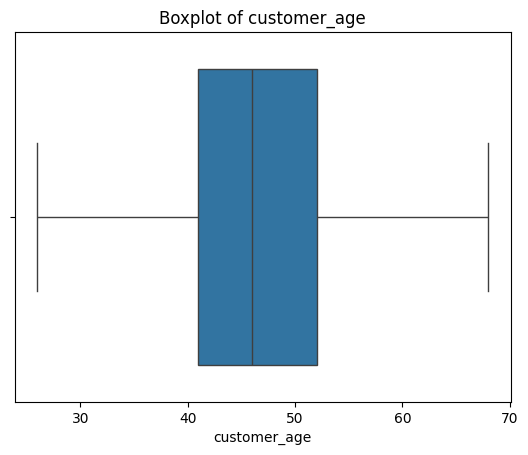

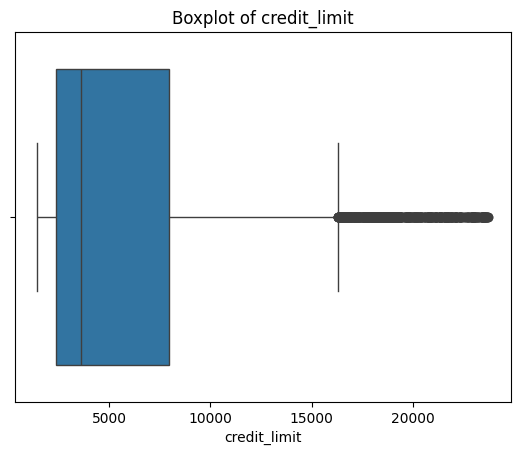

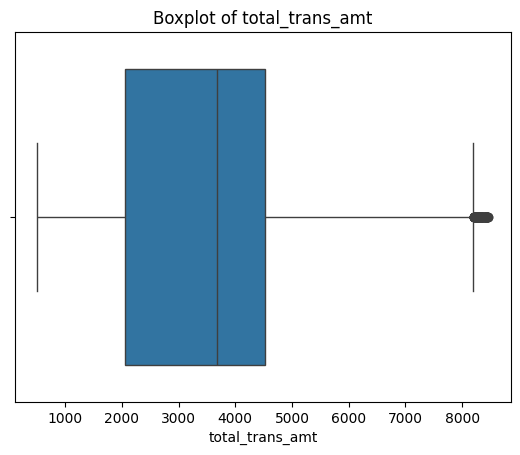

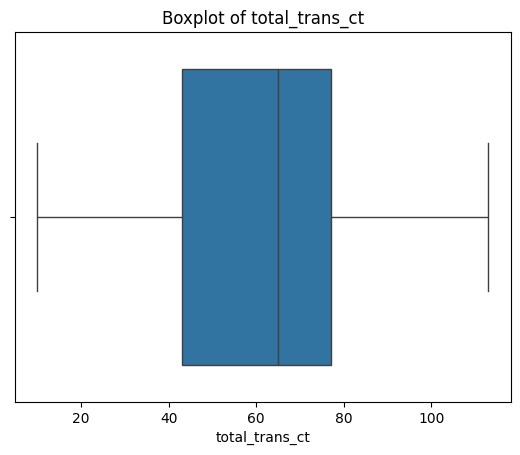

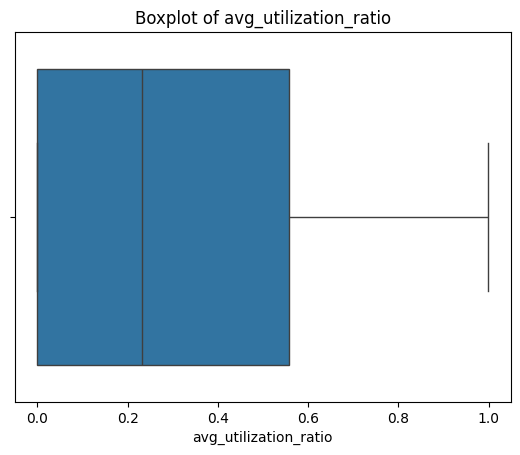

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

#checking for extreme values outside the whiskers

for col in numeric_cols:
    sns.boxplot(data=df, x=col)
    plt.title(f"Boxplot of {col}")
    plt.show()

In [43]:
import numpy as np


## Coding Below For Log Transformation
This will ensure there is no skewed data

In [ ]:
df['log_credit_limit'] = np.log1p(df['credit_limit'])  # Using log1p to handle zero or negative values in credit_limit
# Display the first few rows of the modified DataFrame
print(df[['credit_limit', 'log_credit_limit']].head())

   credit_limit  log_credit_limit
0       12691.0          9.448727
1        8256.0          9.018817
2        3418.0          8.137103
3        3313.0          8.105911
4        4716.0          8.458928


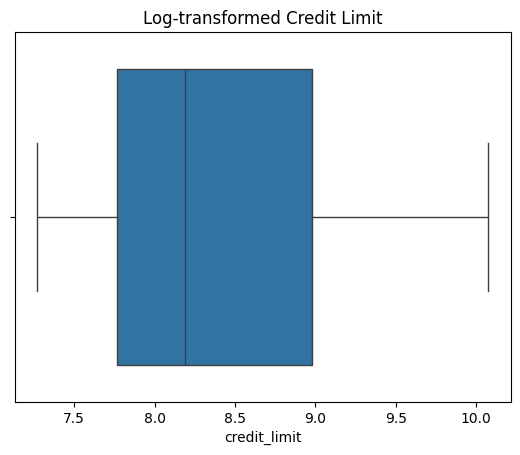

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt
# Visualizing the log-transformed credit limit.

sns.boxplot(data=df, x=np.log1p(df['credit_limit']))
plt.title("Log-transformed Credit Limit")
plt.show()

As you can see above bosxplot the log-transformed credit limit distribution looks much more normalized compared to the original raw values.
The transformation has successfully compressed extreme outliers, making the spread more manageable while preserving overall trends.


In [46]:

#Applying log transformation to additional financial metrics can help smooth skewed distributions, especially for variables with extreme values. This can enhance model performance and interpretability. 


log_cols = ['total_trans_amt', 'avg_utilization_ratio', 'total_trans_ct']
for col in log_cols:
    df[f'log_{col}'] = np.log1p(df[col])

print(df[['total_trans_amt', 'log_total_trans_amt']].head())  # Sample check

   total_trans_amt  log_total_trans_amt
0             1144             7.043160
1             1291             7.163947
2             1887             7.543273
3             1171             7.066467
4              816             6.705639


Applying Log Transformation to Multiple Columns

In [47]:
import numpy as np

# List of columns to apply log transformation
log_columns = ['credit_limit', 'total_trans_amt', 'total_trans_ct', 'avg_utilization_ratio']

# Apply log transformation to each column
for col in log_columns:
    df[f'log_{col}'] = np.log1p(df[col])  # log1p prevents issues with zero values

# Check the transformed values
print(df[[f'log_{col}' for col in log_columns]].describe())

       log_credit_limit  log_total_trans_amt  log_total_trans_ct  \
count       8418.000000          8418.000000         8418.000000   
mean           8.371153             8.030389            4.062397   
std            0.769880             0.511113            0.377377   
min            7.271912             6.236370            2.397895   
25%            7.763977             7.632038            3.784190   
50%            8.191878             8.208764            4.189655   
75%            8.977998             8.416046            4.356709   
max           10.075043             9.043577            4.736198   

       log_avg_utilization_ratio  
count                8418.000000  
mean                    0.245912  
std                     0.210965  
min                     0.000000  
25%                     0.000000  
50%                     0.209045  
75%                     0.442761  
max                     0.692647  


visualizing the log-transformed data to confirm that the extreme values have been smoothed out


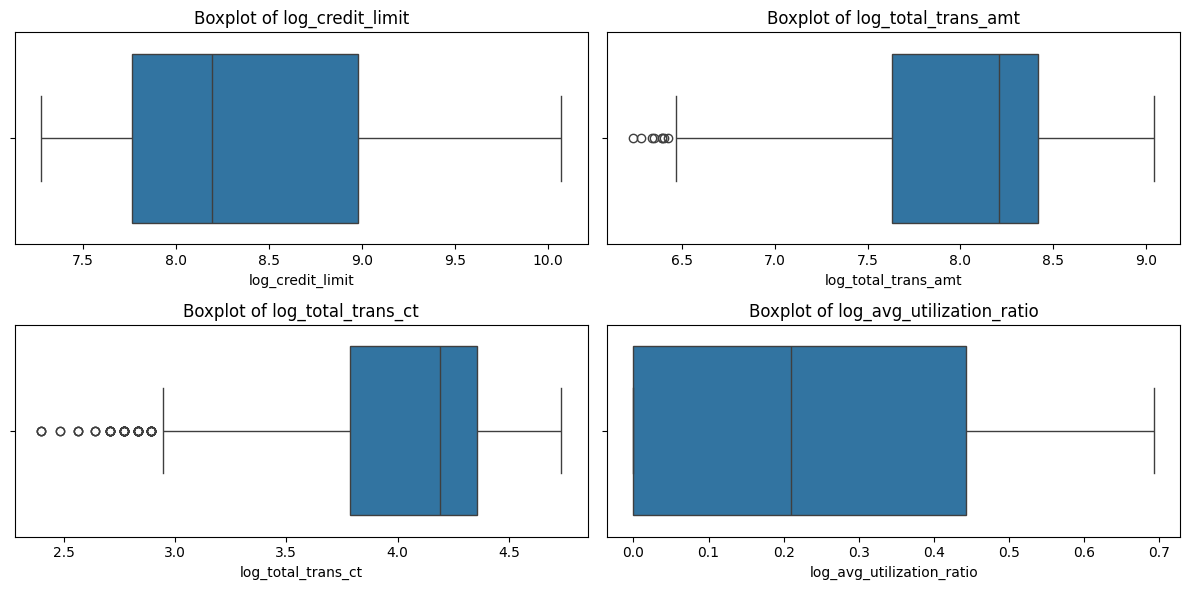

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

# List of log-transformed columns
log_columns = ['log_credit_limit', 'log_total_trans_amt', 'log_total_trans_ct', 'log_avg_utilization_ratio']

# Create boxplots
plt.figure(figsize=(12, 6))
for i, col in enumerate(log_columns, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=df, x=col)
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

The transformation has compressed extreme values, making the distributions more balanced and improving interpretability.
- Log Credit Limit: Nicely centered with no extreme outliers, meaning high-credit customers are now better integrated into the dataset.
- Log Total Transaction Amount: Slight compression of lower values, but still maintaining the overall range.
- Log Total Transaction Count: Some minor outliers at the lower end, which is expected.
- Log Average Utilization Ratio: Looks well-balanced with a smooth distribution.



## Attrition Flag Column 

The below coding ensures that attrition flag column data is cleaned and is suitable for Power BI visualizations.


In [65]:
df['attrition_flag'] = df['attrition_flag'].map({'Existing Customer': 1, 'Attrited Customer': 0})  # Convert categorical to numerical for ease of use on Power BI


In [66]:
df[['attrition_flag']].head()  #Look at the transformed target variable

,attrition_flag
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN


In [67]:
df['attrition_flag'].unique() #checking for unexpected values in the target variable

array([nan])

In [68]:
df['attrition_flag'] = df['attrition_flag'].fillna(-1)  # Fill any remaining NaN values in the target variable with -1 for consistency

In [69]:
df[['attrition_flag']].head() #check the final target variable values

,attrition_flag
0,-1.0
1,-1.0
2,-1.0
3,-1.0
4,-1.0


In [70]:
df['attrition_flag'].value_counts() #This will show how many customers are retained (1) versus attrited (0).


attrition_flag
-1.0    8418
Name: count, dtype: int64

In [71]:
df['attrition_flag'].unique()  # Checking for unexpected values in the target variable after filling NaNs

array([-1.])

In [72]:
print(df.head())  # Display the first few rows of the cleaned DataFrame
print(df.info())  # Display DataFrame information
print(df[['attrition_flag']].value_counts())

   clientnum  attrition_flag  customer_age gender  dependent_count  \
0  768805383            -1.0            45      M                3   
1  818770008            -1.0            49      F                5   
2  713982108            -1.0            51      M                3   
3  769911858            -1.0            40      F                4   
4  709106358            -1.0            40      M                3   

  education_level marital_status income_category card_category  \
0     High School        Married     $60K - $80K          Blue   
1        Graduate         Single  Less than $40K          Blue   
2        Graduate        Married    $80K - $120K          Blue   
3     High School        Unknown  Less than $40K          Blue   
4      Uneducated        Married     $60K - $80K          Blue   

   months_on_book  ...  total_trans_amt  total_trans_ct  total_ct_chng_q4_q1  \
0              39  ...             1144              42                1.625   
1              44  ...

In [73]:
df.to_csv('cleaned_credit_card_data.csv', index=False)